# Знакомство с `torch.Tensor`

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы: 
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann
* https://pytorch.org/docs/stable/torch.html


## Задачи для совместного разбора

In [1]:
import torch
import torch.nn as nn

1\. Создайте тензор и исследуйте его основные характеристики

In [42]:
t = torch.tensor([i for i in range(10)])
t.shape, tensor.dtype, tensor.element_size()

(torch.Size([10]), torch.int64, 8)

2\. Создайте трехмерный тензор и рассмотрите основные способы индексирования по нему

In [43]:
t = torch.arange(24).reshape(2, 3, 4)
t

tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11]],

        [[12, 13, 14, 15],
         [16, 17, 18, 19],
         [20, 21, 22, 23]]])

In [44]:
t[0, :, :]

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])

In [45]:
t[:, 0, :]

tensor([[ 0,  1,  2,  3],
        [12, 13, 14, 15]])

In [46]:
t[:, :, 0]

tensor([[ 0,  4,  8],
        [12, 16, 20]])

In [47]:
t[[0, 1]]

tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11]],

        [[12, 13, 14, 15],
         [16, 17, 18, 19],
         [20, 21, 22, 23]]])

3\. Создайте тензор (4х4) и модифицируйте следующим образом: ко всем четным столбцам прибавьте 1, из нечетных вычтите 1.

In [57]:
t = torch.rand(4, 4)
t

tensor([[0.0709, 0.1731, 0.3758, 0.6025],
        [0.6605, 0.7330, 0.3656, 0.6707],
        [0.1849, 0.6803, 0.6621, 0.2228],
        [0.7866, 0.5915, 0.8828, 0.0328]])

In [58]:
t[:, 1::2] += 1
t[:, ::2] -= 1
t

tensor([[-0.9291,  1.1731, -0.6242,  1.6025],
        [-0.3395,  1.7330, -0.6344,  1.6707],
        [-0.8151,  1.6803, -0.3379,  1.2228],
        [-0.2134,  1.5915, -0.1172,  1.0328]])

4\. Обсудите совместимость `torch` с `numpy` и `sklearn`

In [59]:
import numpy as np
import sklearn

In [67]:
arr = np.array(t)
arr, type(arr)

(array([[-0.9290898 ,  1.1730715 , -0.6241775 ,  1.6024582 ],
        [-0.3395114 ,  1.7330241 , -0.6343648 ,  1.6706843 ],
        [-0.81508195,  1.6802728 , -0.33790052,  1.2228382 ],
        [-0.213408  ,  1.5915213 , -0.11719579,  1.0327759 ]],
       dtype=float32),
 numpy.ndarray)

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Создайте двумерный тензор размера (100000, 10), заполненный нулями. Используя прихотливое индексирование, поставьте в каждой строке тензора ровно одну единицу в случайно выбранном столбце. Рассчитайте и выведите на экран вероятности $p_i$ того, что для случайно выбранной строки в столбце $i$ будет стоять единица.

- [ ] Проверено на семинаре

In [74]:
import random

In [117]:
zeros_t = torch.zeros(100000, 10)
for i in range(zeros_t.shape[0]):
    line = random.randint(0, zeros_t.shape[1] - 1)
    zeros_t[i, line] = 1

zeros_t.sum(dim=0) / zeros_t.shape[0]

tensor([0.1001, 0.1009, 0.0993, 0.1001, 0.1010, 0.0987, 0.0976, 0.1013, 0.1009,
        0.1002])

In [118]:
n_rows = 100000
n_cols = 10

x = torch.zeros((n_rows, n_cols))
cols = torch.randint(0, n_cols, (n_rows,))
rows = torch.arange(n_rows)
x[rows, cols] = 1
probs = x.mean(dim=0)

print(probs)

tensor([0.1010, 0.1004, 0.0993, 0.1001, 0.1009, 0.1001, 0.0994, 0.1005, 0.1003,
        0.0981])


<p class="task" id="2"></p>

2\. При помощи прихотливого индексирования для двумерного тензора размерности (10, 10), состоящего из случайных целых чисел в пределах от 0 до 10, получите тензор элементов, находящихся сразу над  побочной диагональю.

- [ ] Проверено на семинаре

In [133]:
n_rows = 10
n_cols = 10

x = torch.randint(10, (n_rows, n_cols))
print(x)
x[[i for i in range (8, 0, -1)], [i for i in range (0, 8)]]

tensor([[9, 7, 2, 2, 1, 0, 1, 5, 0, 2],
        [7, 3, 0, 9, 8, 9, 9, 3, 9, 9],
        [4, 6, 6, 5, 9, 8, 3, 1, 1, 9],
        [6, 0, 8, 7, 9, 1, 7, 4, 6, 0],
        [2, 9, 5, 7, 4, 1, 8, 2, 7, 2],
        [3, 0, 1, 6, 2, 7, 3, 1, 9, 5],
        [6, 1, 4, 5, 3, 2, 3, 5, 3, 5],
        [1, 3, 3, 6, 7, 6, 5, 2, 2, 7],
        [1, 8, 0, 1, 4, 2, 5, 4, 3, 2],
        [4, 4, 2, 8, 0, 8, 4, 7, 3, 7]])


tensor([1, 3, 4, 6, 4, 1, 3, 3])

<p class="task" id="3"></p>

3\. Создайте двумерный тензор $t$ размерности (5, 5), состоящий из случайных чисел в пределах от 0 до 100. Обнулить все значения в массиве, расположенные вне квадрата размера 3х3 вокруг максимального элемента. Если максимумов несколько, обнулите элементы около любого из них.

- [ ] Проверено на семинаре

In [234]:
n_rows = 5
n_cols = 5

x = torch.randint(101, (n_rows, n_cols))
print("Исходный тензор:")
print(x)

flat_idx = torch.argmax(x)
row, col = torch.unravel_index(flat_idx, x.shape)

print(f"\nМаксимум = {x[row, col].item()}  находится в позиции [{row}, {col}]")

mask = torch.zeros_like(x, dtype=torch.bool)

r_start = max(0, row - 1)
r_end   = min(5, row + 2)
c_start = max(0, col - 1)
c_end   = min(5, col + 2)

mask[r_start:r_end, c_start:c_end] = True

y = x.clone()
y[~mask] = 0

print(y)

Исходный тензор:
tensor([[68, 74, 24, 18, 39],
        [75, 53,  8, 97, 74],
        [53, 42, 90, 23, 48],
        [73, 20, 98,  7, 26],
        [39,  7, 61, 38, 68]])

Максимум = 98  находится в позиции [3, 2]
tensor([[ 0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0],
        [ 0, 42, 90, 23,  0],
        [ 0, 20, 98,  7,  0],
        [ 0,  7, 61, 38,  0]])


<p class="task" id="4"></p>

4\. Создайте трехмерный массив размерности (2, 5, 5) на основе решения задачи 3 (объедините исходный и результирущий тензор вдоль нулевой оси). Сохраните полученный трехмерный тензор в файл `tensor.pt`. Загрузите полученный тензор и покажите, что все элементы двух тензоров совпадают.

- [ ] Проверено на семинаре

In [236]:
tensor_3d = torch.stack([x, y], dim=0)
tensor_3d.shape

torch.Size([2, 5, 5])

In [240]:
torch.save(tensor_3d, "tensor.pt")
print("Тензор сохранён в файл: tensor.pt")

Тензор сохранён в файл: tensor.pt


In [243]:
# Проверяем, что загрузка работает корректно
loaded = torch.load("tensor.pt")

print("Проверка после загрузки:")
print("Размеры совпадают →", loaded.shape == tensor_3d.shape, loaded.shape, tensor_3d.shape)
print("Все элементы совпадают →", torch.equal(loaded, tensor_3d))

Проверка после загрузки:
Размеры совпадают → True torch.Size([2, 5, 5]) torch.Size([2, 5, 5])
Все элементы совпадают → True


<p class="task" id="5"></p>

5\. Создайте четырехмерный массив `t` размерности (2, 3, 5, 5), заполненный случайными целыми числами от 1 до 10 (сами значения должны быть представлены типом float32). Рассчитайте среднее значение для каждого двумерного тензора `t[i, j, :, :]`. Представьте результат в виде трехмерного тензора размера (2, 3, 1).

- [ ] Проверено на семинаре

In [245]:
t = torch.randint(1, 11, size=(2, 3, 5, 5), dtype=torch.float32)

mean_per_slice = t.mean(dim=(-2, -1), keepdim=True)

result = mean_per_slice.squeeze(-1)


print("Исходный тензор t.shape:", t.shape)
print("Результат shape:", result.shape)
print("\nСредние значения для каждого 5×5 среза:")
print(result)

Исходный тензор t.shape: torch.Size([2, 3, 5, 5])
Результат shape: torch.Size([2, 3, 1])

Средние значения для каждого 5×5 среза:
tensor([[[5.4000],
         [5.4000],
         [6.1200]],

        [[5.4000],
         [5.4800],
         [6.0000]]])


<p class="task" id="6"></p>

6\. Создайте одномерный тензор размера `N=100_000_000`, заполненный числами из экспоненциального распредления с параметром $\lambda=5$. Рассчитайте значения для построения гистограммы при помощи пакета `torch`. Визуализируйте гистограмму. Проверьте возможность использования GPU. При наличии GPU перенесите созданный тензор в память GPU, повторите вычисления. Сравните время расчетом с и без использования GPU.

- [ ] Проверено на семинаре

In [247]:
import time
import matplotlib.pyplot as plt

In [249]:
# Параметры
N = 100_000_000          # 100 миллионов элементов
lambda_param = 1.0       # параметр экспоненциального распределения (scale = 1/λ)
bins = 300               # количество столбцов в гистограмме
device_gpu = "cuda" if torch.cuda.is_available() else "cpu"

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device name    : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version: 2.10.0+cpu
CUDA available : False


In [250]:
# ─── Функция для замера времени и построения гистограммы ────────
def compute_histogram(data_tensor, device_name="cpu"):
    t0 = time.perf_counter()
    
    # Переводим на нужное устройство (если ещё не там)
    data = data_tensor.to(device_name)
    
    # Гистограмма через torch.histogram
    hist, bin_edges = torch.histogram(
        data,
        bins=bins,
        range=(0, 8),           # большинство значений лежит в [0..~8] при λ=1
        density=False
    )
    
    t_hist = time.perf_counter() - t0
    
    # Переносим на CPU для matplotlib (если был на GPU)
    hist = hist.float().cpu().numpy()
    bin_edges = bin_edges.cpu().numpy()
    
    return hist, bin_edges, t_hist

In [251]:
t0 = time.perf_counter()
x = torch.distributions.Exponential(rate=lambda_param).sample((N,))
gen_time = time.perf_counter() - t0
print(f"Генерация {N:,} элементов: {gen_time:.2f} сек")

Генерация 100,000,000 элементов: 1.95 сек


In [ ]:
# Вариант 1: CPU
print("\n=== CPU ===")
hist_cpu, edges_cpu, time_cpu = compute_histogram(x, device_name="cpu")
print(f"Время построения гистограммы (CPU): {time_cpu:.3f} сек")

In [254]:
# Вариант 2: GPU (если доступен)
time_gpu = None
if torch.cuda.is_available():
    print("\n=== GPU ===")
    x_gpu = x.to("cuda")
    
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    hist_gpu, edges_gpu, time_gpu = compute_histogram(x_gpu, device_name="cuda")
    torch.cuda.synchronize()
    time_gpu_total = time.perf_counter() - t0
    
    print(f"Время построения гистограммы (GPU): {time_gpu:.3f} сек")
    print(f"Ускорение гистограммы: {time_cpu / time_gpu:.1f}×" if time_gpu > 0 else "—")
    
    # Сравниваем результаты
    diff = torch.abs(hist_cpu - hist_gpu.cpu())
    print(f"Максимальная разница между CPU и GPU гистограммами: {diff.max().item():.2e}")
else:
    print("GPU недоступен → сравнение не проводится")

GPU недоступен → сравнение не проводится


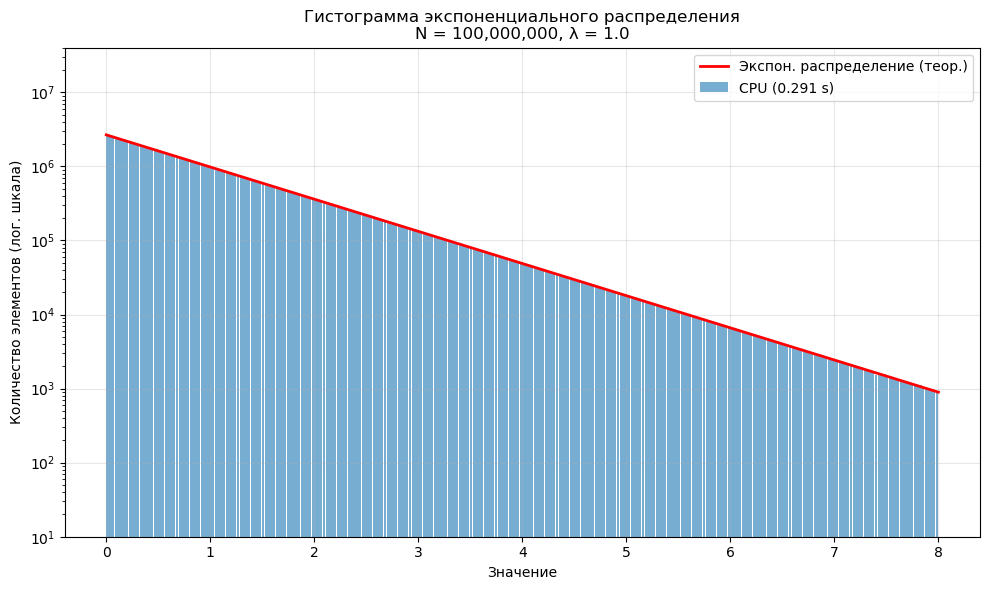

In [255]:
# ─── Визуализация (всегда на CPU) ───────────────────────────────
plt.figure(figsize=(10, 6))

centers = (edges_cpu[:-1] + edges_cpu[1:]) / 2

plt.bar(centers, hist_cpu, width=(edges_cpu[1]-edges_cpu[0])*0.9,
        alpha=0.6, label=f"CPU ({time_cpu:.3f} s)", color="C0")

if time_gpu is not None:
    plt.bar(centers, hist_gpu, width=(edges_gpu[1]-edges_gpu[0])*0.45,
            alpha=0.5, label=f"GPU  ({time_gpu:.3f} s)", color="C1", align="right")

# Теоретическая плотность
x_th = torch.linspace(0, 8, 200)
pdf = lambda_param * torch.exp(-lambda_param * x_th)
plt.plot(x_th, pdf * N * (edges_cpu[1]-edges_cpu[0]), 
         'r-', lw=2, label="Экспон. распределение (теор.)")

plt.yscale("log")
plt.ylim(1e1, N*0.4)
plt.xlabel("Значение")
plt.ylabel("Количество элементов (лог. шкала)")
plt.title(f"Гистограмма экспоненциального распределения\nN = {N:,}, λ = {lambda_param}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<p class="task" id="7"></p>

7\. Создайте четырехмерный тензор размера (10, 6, 6, 3), заполненный случайными целыми числами от 0 до 255. Считая, что данный тензор представляет собой батч из 10 картинок размера 6х6 в формате RGB, измените тензор следующим образом. Для оттенков красного обнулите все столбцы, кроме первых двух; для оттенков зеленого обнулите третий и четвертый столбцы; для оттенков синего обнулите пятый и шестой столбцы. Для выполнения задания используйте механизм распространения.

- [ ] Проверено на семинаре

In [266]:
import torch

imgs = torch.randint(0, 256, (10, 6, 6, 3))

mask = torch.ones(6, 3)

mask[2:, 0] = 0
mask[2:4, 1] = 0
mask[4:, 2] = 0

imgs = imgs * mask.unsqueeze(0).unsqueeze(0)
imgs.shape

torch.Size([10, 6, 6, 3])